In [34]:
# A = [[1, 2], [3, 4]]
# B = [[1, 2, 3], [4, 5, 6]]
import math
import numpy as np
from torchvision.datasets import MNIST
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

def matrix_mult(M, N):
    m, n, r = len(M), len(M[0]), len(N[0])
    assert n == len(N), f"{m}x{n} and {len(N)}x{r} matrices sizes incompatible"

    result = [[0 for _ in range(r)] for _ in range(m)]

    for i in range(m):
        for j in range(r):
            sum = 0
            for k in range(n):
                sum += M[i][k] * N[k][j]
            result[i][j] = sum
    return result

def matrix_scalar_mult(c, M):
    m, n = len(M), len(M[0])
    scaled = [[c * M[i][j] for j in range(n)] for i in range(m)]

    return scaled

def matrix_add(M, N):
    m, n = len(M), len(M[0])
    assert m == len(N) and n == len(N[0]), f"{m}x{n} and {len(N)}x{len(N[0])} matrices sizes incompatible"

    result = [[M[i][j] + N[i][j] for j in range(n)] for i in range(m)]
    return result

def matrix_sub(M, N):
    m, n = len(M), len(M[0])
    assert m == len(N) and n == len(N[0]), f"{m}x{n} and {len(N)}x{len(N[0])} matrices sizes incompatible"

    result = [[M[i][j] - N[i][j] for j in range(n)] for i in range(m)]
    return result

def hadamard(M, N):
    m, n = len(M), len(M[0])
    assert m == len(N) and n == len(N[0]), f"{m}x{n} and {len(N)}x{len(N[0])} matrices sizes incompatible"

    result = [[M[i][j] * N[i][j] for j in range(n)] for i in range(m)]
    return result

def vector_softmax(z):
    m, n = len(z), len(z[0])

    assert n == 1, f"This function only works on vectors, not a {m}x{n} matrix"
    result = [[0.0 for _ in range(n)] for _ in range(m)]

    sum = 0.0
    for i in range(m):
        for j in range(n):
            e = math.exp(z[i][j])
            result[i][j] = e
            sum += e

    return matrix_scalar_mult(1/sum, result)
        






def transpose(M):
    m, n = len(M), len(M[0])
    # print(f"{m} x {n}")
    transposed = [[0.0 for _ in range(m)] for _ in range(n)]

    for i in range(m):
        for j in range(n):
            transposed[j][i] = M[i][j]

    return transposed


def sigmoid(x):
    return 1 / (1 + math.exp(-x))

def dsigmoid(x):
    return sigmoid(x) * (1-sigmoid(x))

def vector_dsigmoid(z):
    return [[dsigmoid(z[i][0])] for i in range(len(z))]


def vector_sigmoid(z):
    return [[sigmoid(z[i][0])] for i in range(len(z))]


# quadratic loss
def quadratic_loss(y, a):
    loss = 0.0
    for i in range(len(y)):
        loss += (y[i][0] - a[i][0]) ** 2
    loss /= 2
    return loss

# binary cross entropy loss
def BCE(y, a):
    loss = 0.0
    for i in range(len(y)):
        loss -= y[i][0]*math.log(a[i][0]) + (1 - y[i][0])*math.log((1 - a[i][0]))
    return loss 

# negative log-likelihood loss
def NLL(y, a):
    return -math.log(a[np.argmax(y)][0])

# L2 Regularization
def L2(model, optim):
    weight_decay = optim.weight_decay
    lr = optim.lr

    lambda_over_2n = weight_decay / (2 * lr) # (lambda*lr / n) * 1/(2*lr)

    weight_squared_sum = 0.0
    for layer in model.layers:
        for row in layer.W:
            for weight in row:
                weight_squared_sum += weight ** 2

    return lambda_over_2n * weight_squared_sum

    





def acc(y, a):
    return np.argmax(y) == np.argmax(a)

class Layer:
    def __init__(self, input_neurons, output_neurons, softmax = False):
        self.j = output_neurons
        self.k = input_neurons

        self.W = np.random.normal(scale = 1/math.sqrt(self.j), size = (self.j, self.k)).tolist() # mean = 0, sd = 1.0
        self.b = np.random.normal(size = (self.j, 1)).tolist()

        self.softmax = softmax

        self.clear_grad()

    def __call__(self, prev_activations):
        return self.forward(prev_activations)

    def forward(self, prev_activations):
        z = matrix_add(matrix_mult(self.W, prev_activations), self.b)
        if self.softmax:
            return vector_softmax(z)

        return vector_sigmoid(z), z

    def clear_grad(self):
        self.W_grad = [[0.0 for _ in range(self.k)] for _ in range(self.j)]
        self.b_grad = [[0.0] for _ in range(self.j)]

class Optimizer:
    def __init__(self, lr, batch_size, weight_decay = None):
        self.lr = lr
        self.weight_decay = weight_decay
        self.batch_size = batch_size

    def __call__(self, layer): # update the parameters
        # print(f"{len(layer.W)}x{len(layer.W[0])}, {len(layer.W_grad)}x{len(layer.W_grad[0])}")
        if self.weight_decay is not None:
            layer.W = matrix_scalar_mult(1-self.weight_decay, layer.W)

        layer.W = matrix_sub(layer.W, matrix_scalar_mult(self.lr/self.batch_size, layer.W_grad))
        layer.b = matrix_sub(layer.b, matrix_scalar_mult(self.lr/self.batch_size, layer.b_grad))





class MLP:
    def __init__(self, hidden_neurons):
        self.layers = [
            Layer(784, hidden_neurons),
            Layer(hidden_neurons, 10),
        ]
        self.clear_a_and_z()
        self.optim = Optimizer(1e-3, 64)



    def __call__(self, x):
        return self.forward(x)

    def forward(self, x):
        output = x

        for layer in self.layers: 
            output, weighted_input = layer(output)
            self.activations.append(output)
            self.weighted_inputs.append(weighted_input)

        return output

    def backward(self, x, y):
        L = len(self.layers)
        delta_l_s = [0.0 for _ in range(L)]

        for l in range(L-1, -1, -1):
            a_l = self.activations[l]
            z_l = self.weighted_inputs[l]

            # print(l)
            
            if (l == L - 1): 
                # print(matrix_sub(a_l, y))
                # delta_l = hadamard(matrix_sub(a_l, y), vector_dsigmoid(z_l)) # BP1, quadratic loss
                delta_l = matrix_sub(a_l, y) # BP1, BCE, NLL
            else:
                # print(matrix_mult(transpose(self.layers[l+1].W), delta_l_s[l+1]))
                delta_l = hadamard(matrix_mult(transpose(self.layers[l+1].W), delta_l_s[l+1]), vector_dsigmoid(z_l)) # BP2

            delta_l_s[l] = delta_l

            # BP3
            if (l == 0):
                W_grad = matrix_mult(delta_l, transpose(x))
            else:
                W_grad = matrix_mult(delta_l, transpose(self.activations[l-1]))


            self.layers[l].W_grad = matrix_add(self.layers[l].W_grad, W_grad)
            self.layers[l].b_grad = matrix_add(self.layers[l].b_grad, delta_l) # BP4

            # print(self.layers[l].W_grad)

            # print(f"l: {l} | grad: {self.layers[l].W_grad}")

        self.clear_a_and_z()

        


    def step(self): # update parameters 
        for layer in self.layers:
            self.optim(layer)

    def clear_a_and_z(self):
        self.activations = []
        self.weighted_inputs = []


    def clear_grad(self):
        for layer in self.layers:
            layer.clear_grad()

    def set_optim(self, optim):
        self.optim = optim
        





         


  0%|          | 0/50000 [00:00<?, ?samples/s]

Epoch: 1 | Loss: 0.7170 | Acc: 93.66%


<Figure size 640x480 with 0 Axes>

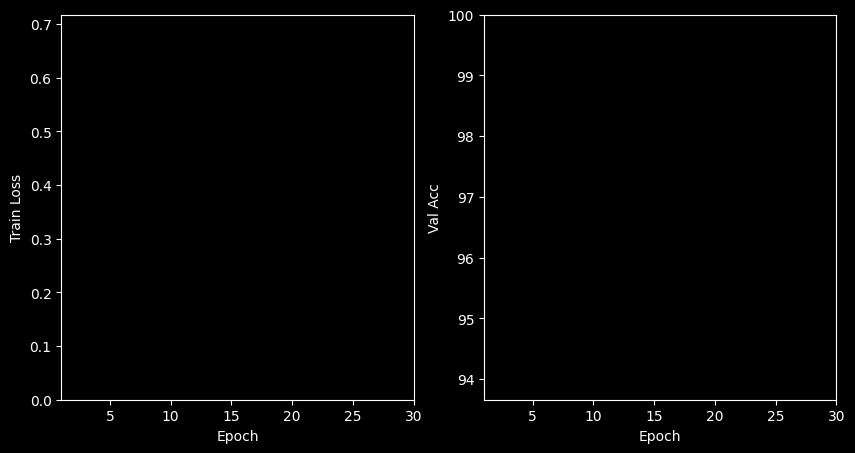

  0%|          | 0/50000 [00:00<?, ?samples/s]

Epoch: 2 | Loss: 0.4236 | Acc: 95.36%


<Figure size 640x480 with 0 Axes>

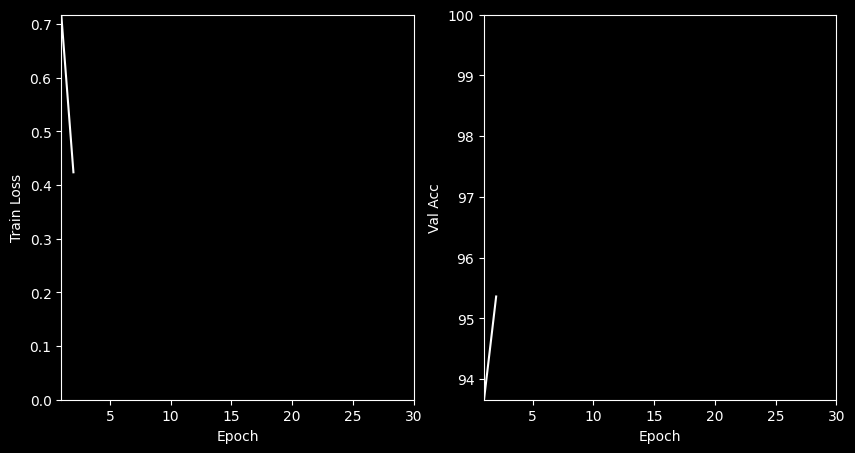

  0%|          | 0/50000 [00:00<?, ?samples/s]

Epoch: 3 | Loss: 0.3345 | Acc: 95.77%


<Figure size 640x480 with 0 Axes>

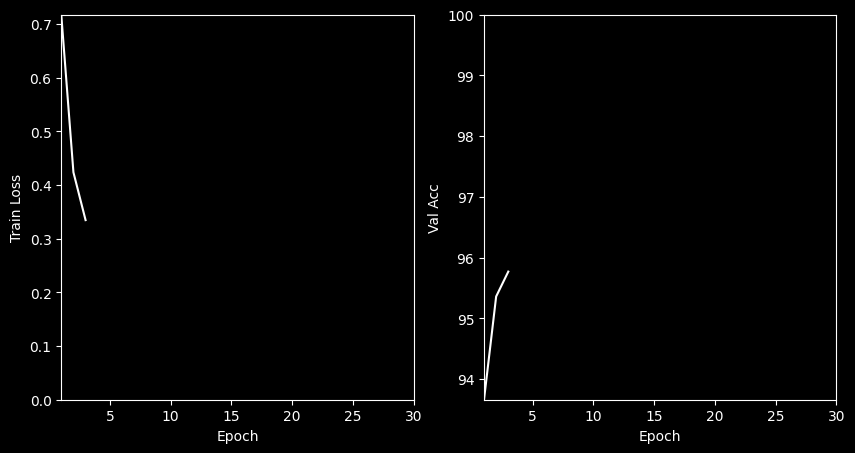

  0%|          | 0/50000 [00:00<?, ?samples/s]

Epoch: 4 | Loss: 0.2840 | Acc: 96.57%


<Figure size 640x480 with 0 Axes>

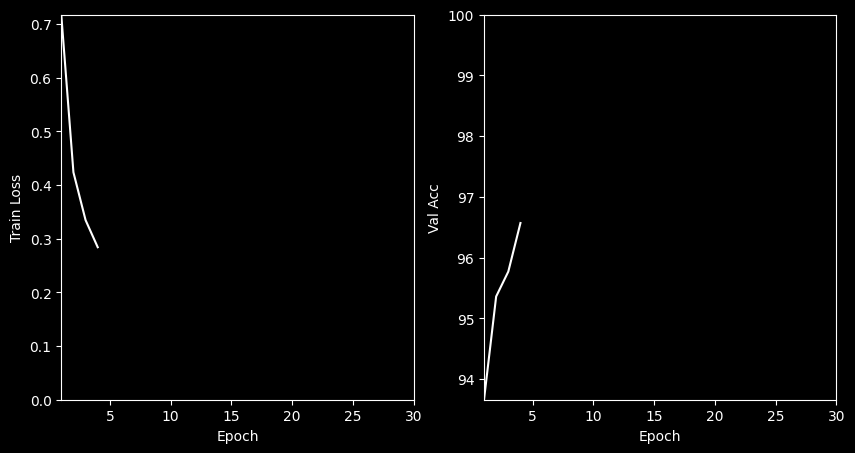

  0%|          | 0/50000 [00:00<?, ?samples/s]

Epoch: 5 | Loss: 0.2502 | Acc: 96.80%


<Figure size 640x480 with 0 Axes>

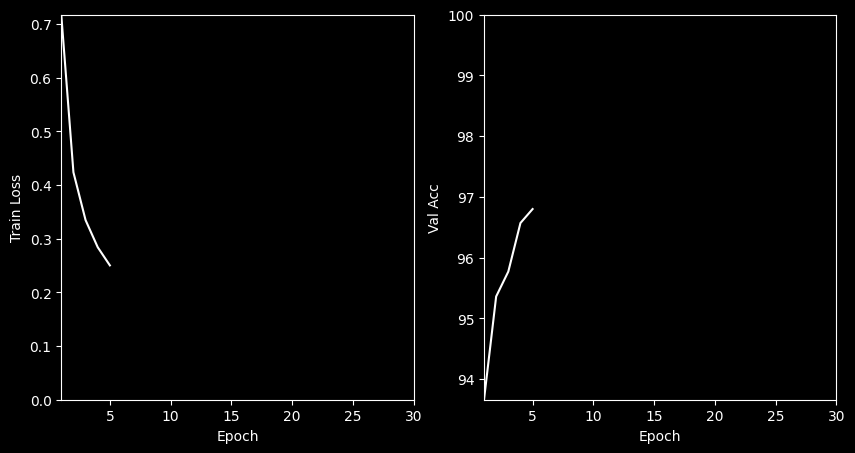

  0%|          | 0/50000 [00:00<?, ?samples/s]

Epoch: 6 | Loss: 0.2258 | Acc: 96.99%


<Figure size 640x480 with 0 Axes>

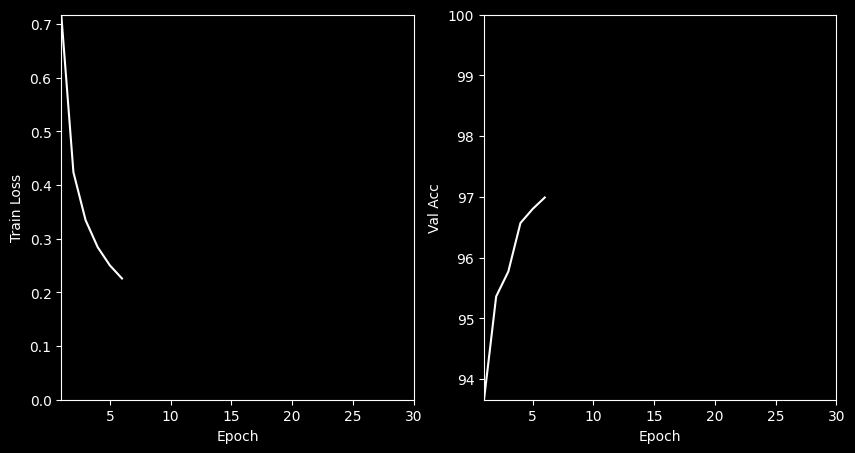

  0%|          | 0/50000 [00:00<?, ?samples/s]

Epoch: 7 | Loss: 0.2071 | Acc: 97.29%


<Figure size 640x480 with 0 Axes>

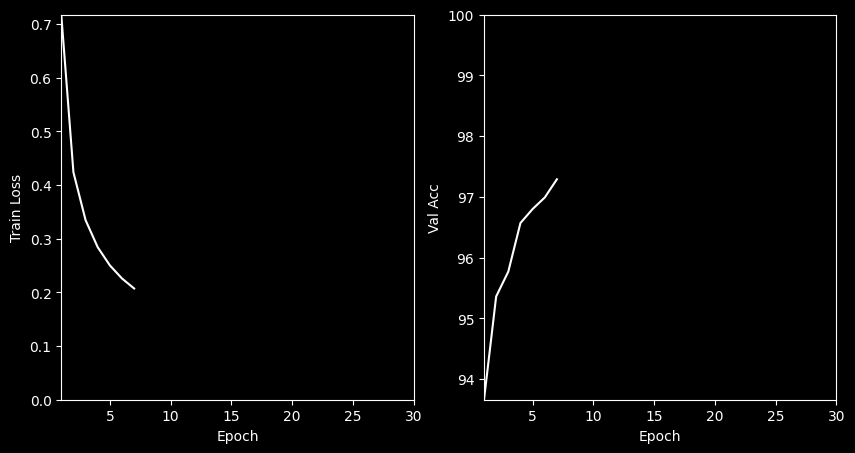

  0%|          | 0/50000 [00:00<?, ?samples/s]

Epoch: 8 | Loss: 0.1920 | Acc: 97.29%


<Figure size 640x480 with 0 Axes>

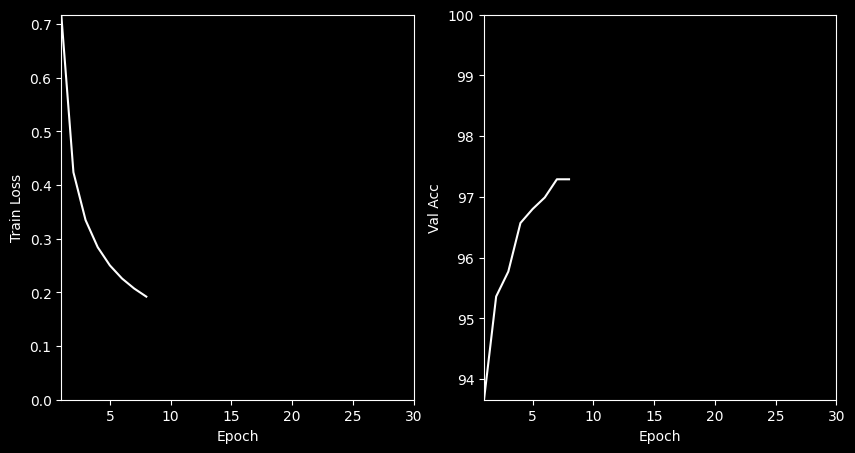

  0%|          | 0/50000 [00:00<?, ?samples/s]

Epoch: 9 | Loss: 0.1808 | Acc: 97.31%


<Figure size 640x480 with 0 Axes>

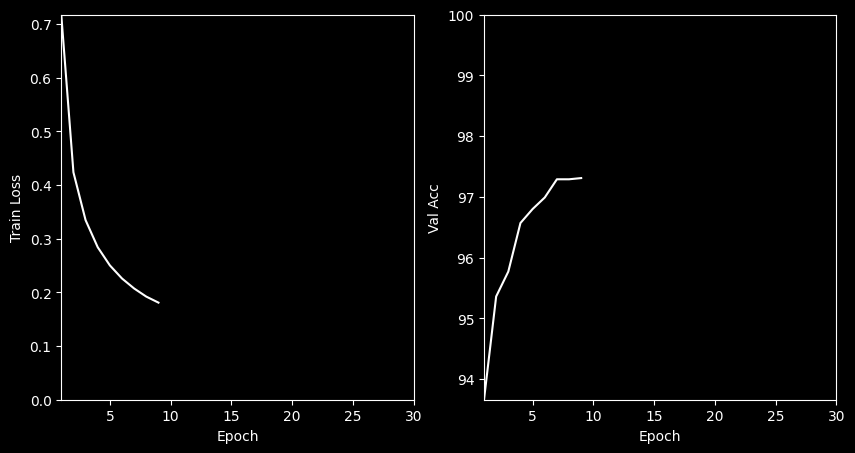

  0%|          | 0/50000 [00:00<?, ?samples/s]

Epoch: 10 | Loss: 0.1703 | Acc: 97.46%


<Figure size 640x480 with 0 Axes>

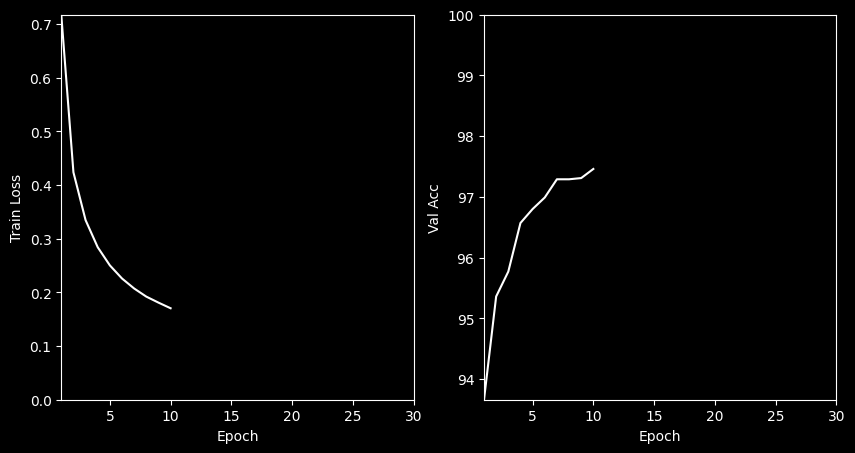

  0%|          | 0/50000 [00:00<?, ?samples/s]

Epoch: 11 | Loss: 0.1621 | Acc: 97.53%


<Figure size 640x480 with 0 Axes>

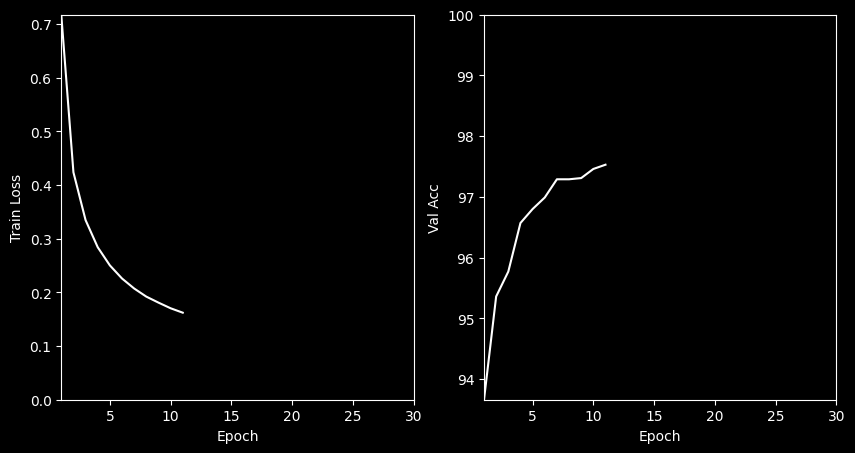

  0%|          | 0/50000 [00:00<?, ?samples/s]

Epoch: 12 | Loss: 0.1555 | Acc: 97.52%


<Figure size 640x480 with 0 Axes>

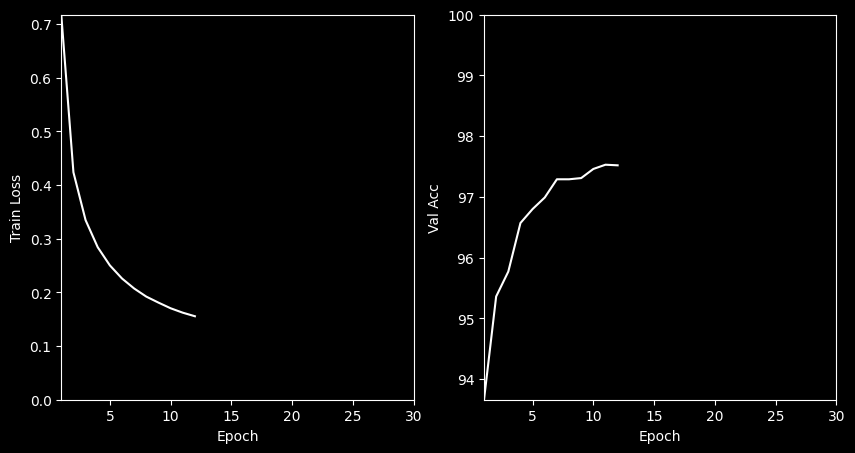

  0%|          | 0/50000 [00:00<?, ?samples/s]

Epoch: 13 | Loss: 0.1497 | Acc: 97.52%


<Figure size 640x480 with 0 Axes>

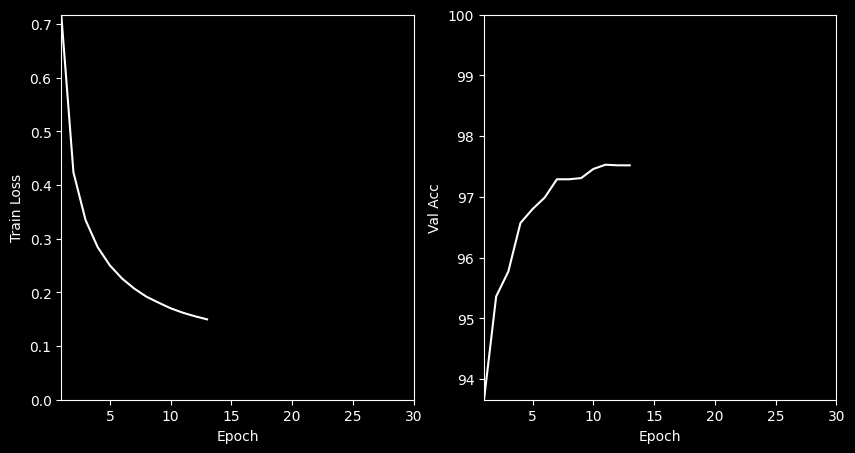

  0%|          | 0/50000 [00:00<?, ?samples/s]

Epoch: 14 | Loss: 0.1442 | Acc: 97.62%


<Figure size 640x480 with 0 Axes>

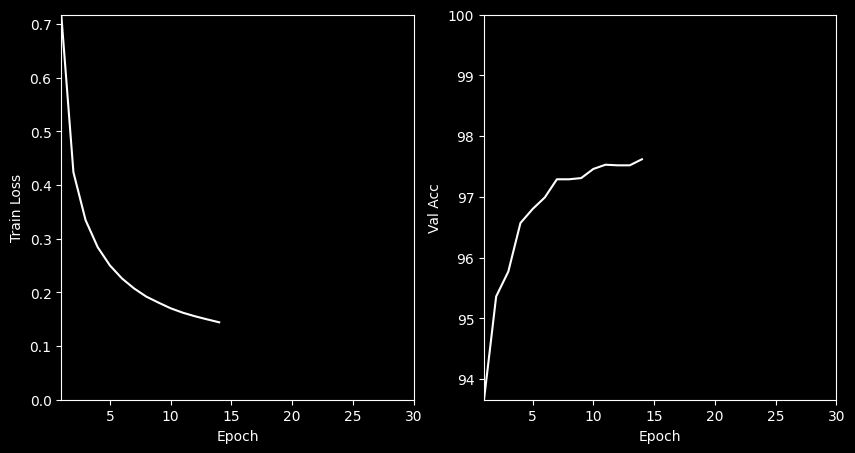

  0%|          | 0/50000 [00:00<?, ?samples/s]

Epoch: 15 | Loss: 0.1398 | Acc: 97.65%


<Figure size 640x480 with 0 Axes>

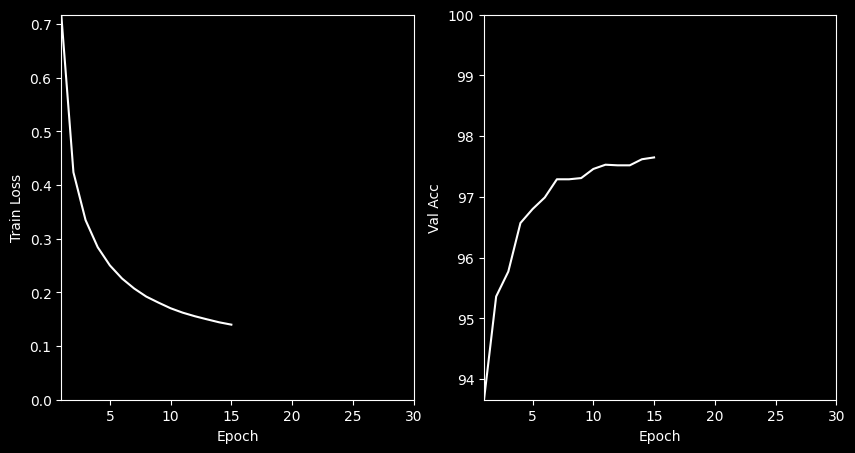

  0%|          | 0/50000 [00:00<?, ?samples/s]

Epoch: 16 | Loss: 0.1353 | Acc: 97.62%


<Figure size 640x480 with 0 Axes>

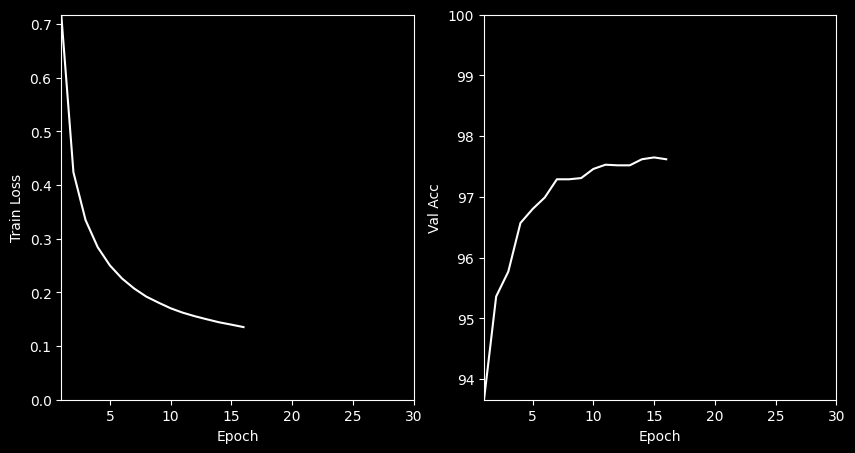

  0%|          | 0/50000 [00:00<?, ?samples/s]

Epoch: 17 | Loss: 0.1315 | Acc: 97.82%


<Figure size 640x480 with 0 Axes>

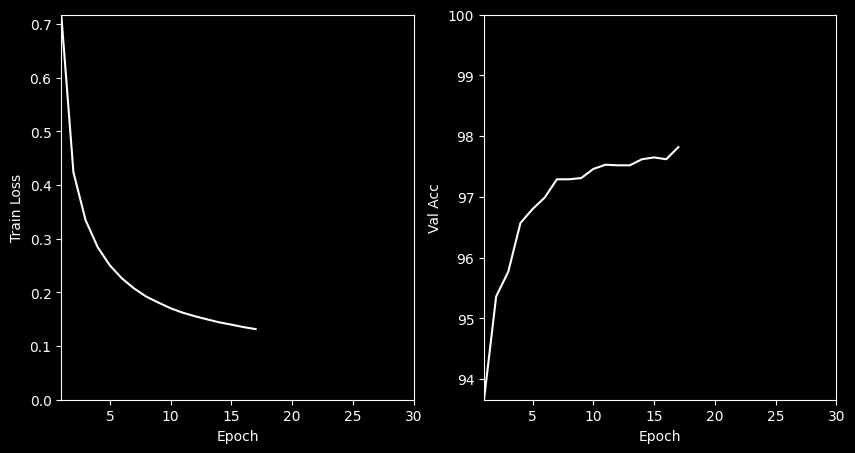

  0%|          | 0/50000 [00:00<?, ?samples/s]

Epoch: 18 | Loss: 0.1284 | Acc: 97.69%


<Figure size 640x480 with 0 Axes>

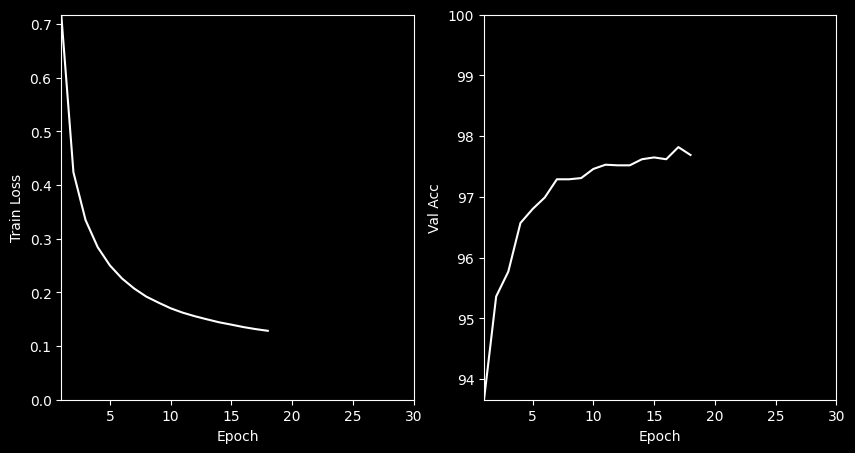

  0%|          | 0/50000 [00:00<?, ?samples/s]

Epoch: 19 | Loss: 0.1257 | Acc: 97.75%


<Figure size 640x480 with 0 Axes>

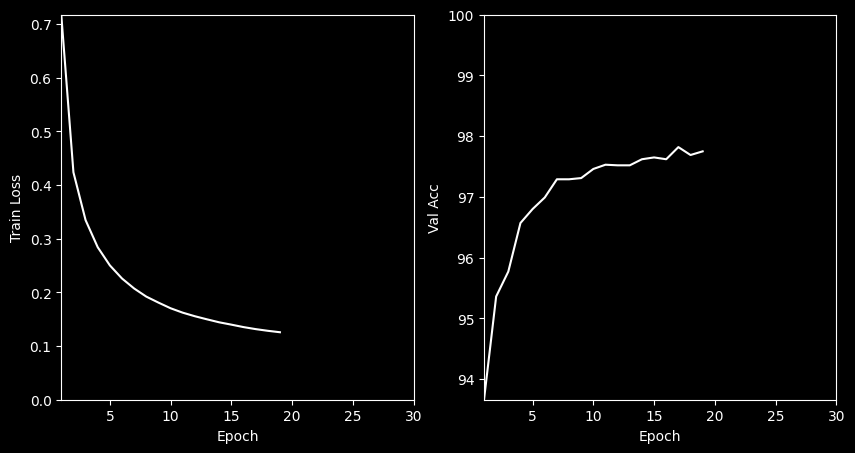

  0%|          | 0/50000 [00:00<?, ?samples/s]

Epoch: 20 | Loss: 0.1231 | Acc: 97.81%


<Figure size 640x480 with 0 Axes>

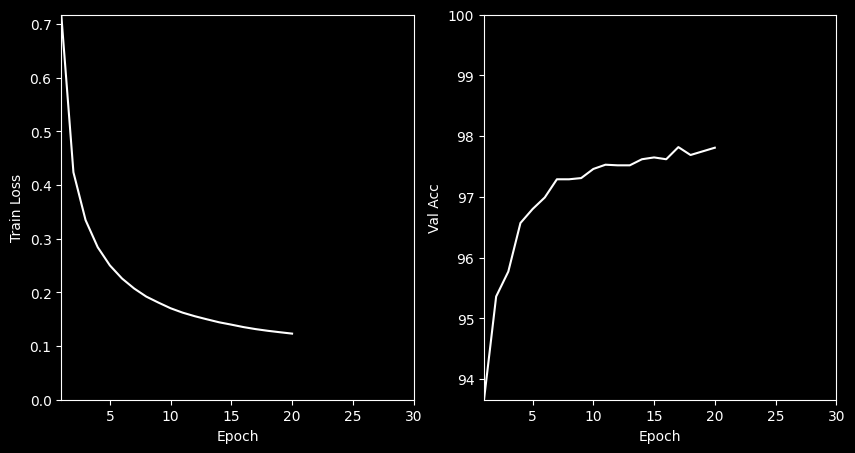

  0%|          | 0/50000 [00:00<?, ?samples/s]

Epoch: 21 | Loss: 0.1205 | Acc: 97.79%


<Figure size 640x480 with 0 Axes>

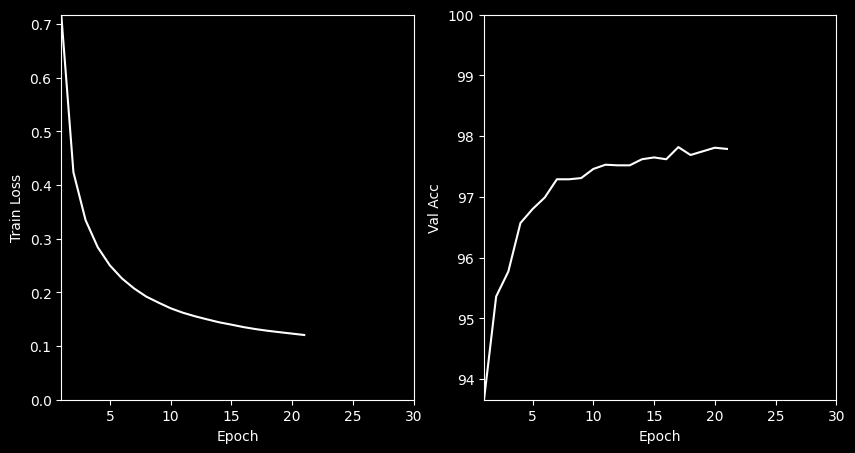

  0%|          | 0/50000 [00:00<?, ?samples/s]

Epoch: 22 | Loss: 0.1180 | Acc: 97.78%


<Figure size 640x480 with 0 Axes>

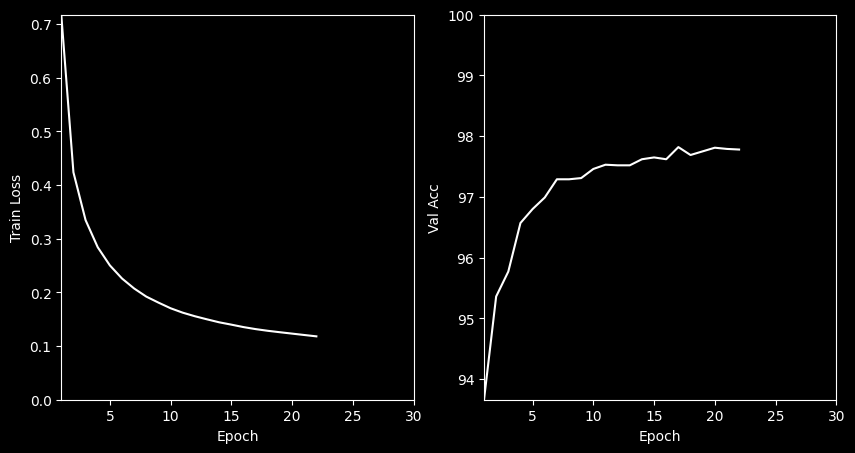

  0%|          | 0/50000 [00:00<?, ?samples/s]

Epoch: 23 | Loss: 0.1167 | Acc: 97.70%


<Figure size 640x480 with 0 Axes>

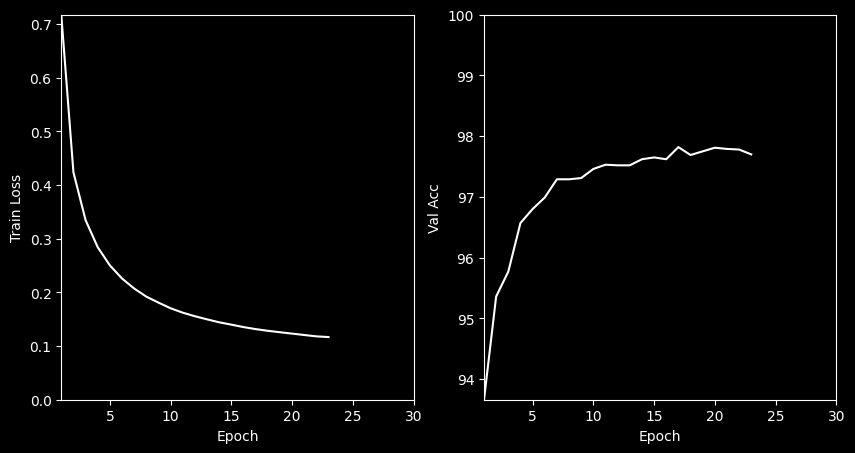

  0%|          | 0/50000 [00:00<?, ?samples/s]

Epoch: 24 | Loss: 0.1148 | Acc: 97.83%


<Figure size 640x480 with 0 Axes>

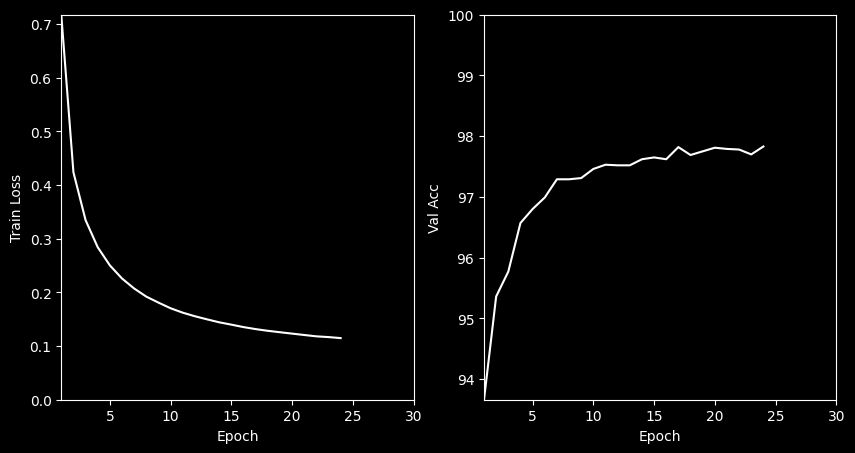

  0%|          | 0/50000 [00:00<?, ?samples/s]

Epoch: 25 | Loss: 0.1128 | Acc: 97.74%


<Figure size 640x480 with 0 Axes>

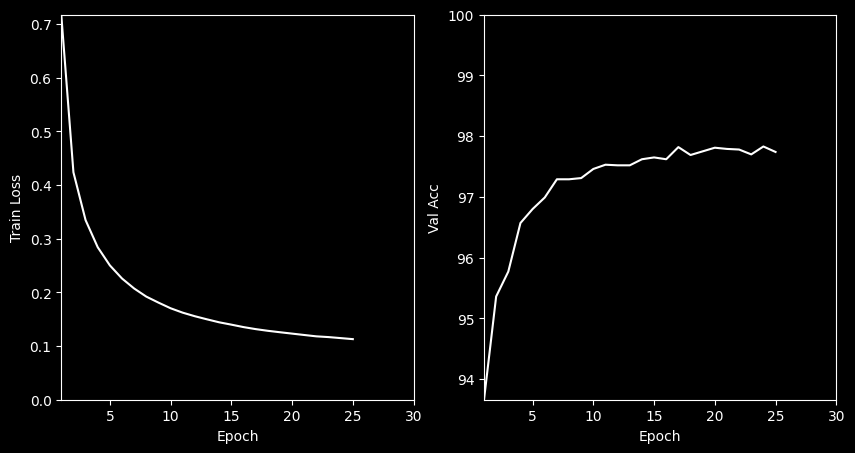

  0%|          | 0/50000 [00:00<?, ?samples/s]

Epoch: 26 | Loss: 0.1114 | Acc: 97.81%


<Figure size 640x480 with 0 Axes>

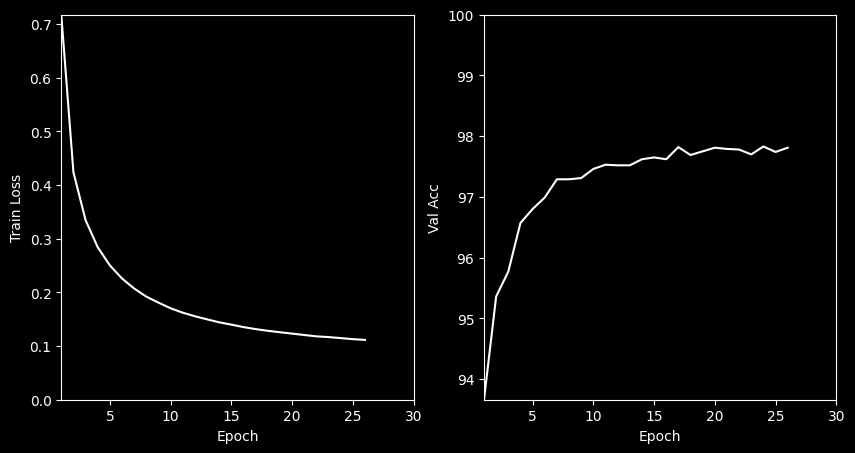

  0%|          | 0/50000 [00:00<?, ?samples/s]

Epoch: 27 | Loss: 0.1105 | Acc: 97.88%


<Figure size 640x480 with 0 Axes>

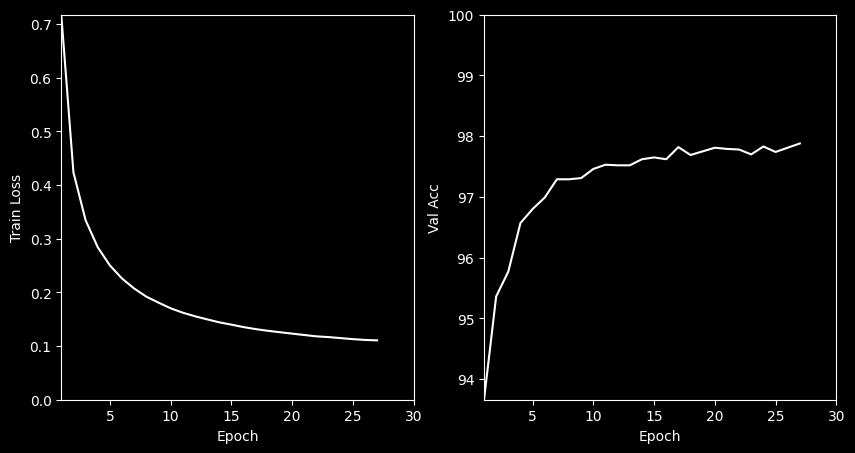

  0%|          | 0/50000 [00:00<?, ?samples/s]

Epoch: 28 | Loss: 0.1092 | Acc: 97.89%


<Figure size 640x480 with 0 Axes>

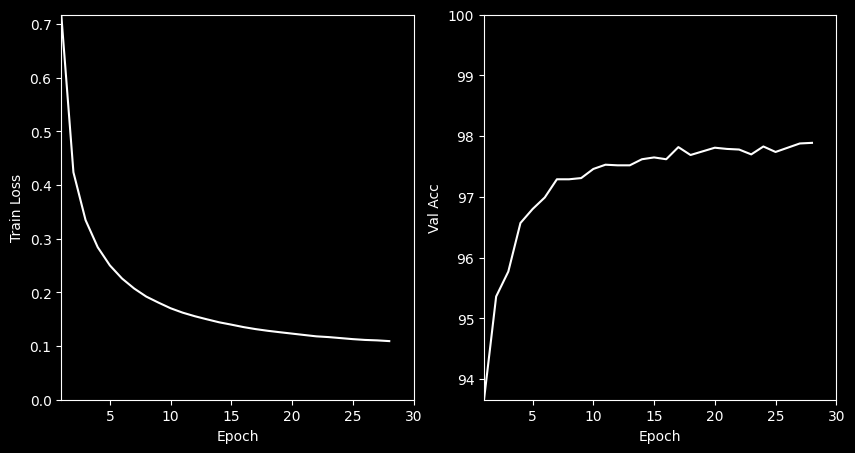

  0%|          | 0/50000 [00:00<?, ?samples/s]

Epoch: 29 | Loss: 0.1078 | Acc: 97.83%


<Figure size 640x480 with 0 Axes>

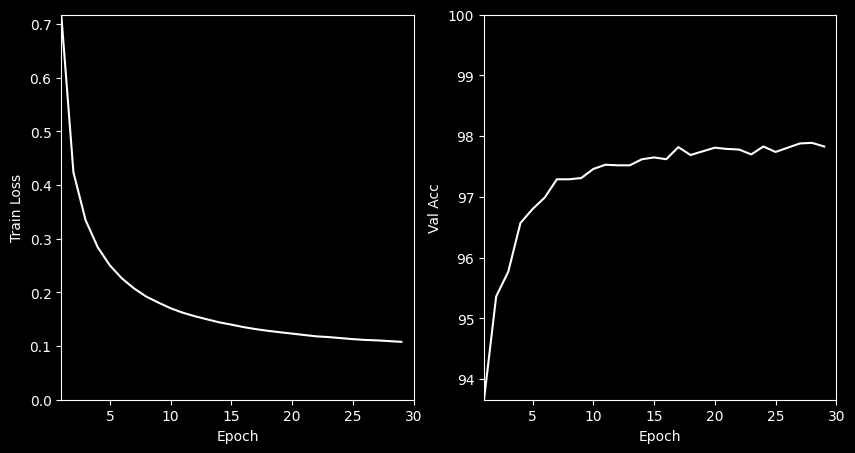

  0%|          | 0/50000 [00:00<?, ?samples/s]

Epoch: 30 | Loss: 0.1069 | Acc: 97.97%


<Figure size 640x480 with 0 Axes>

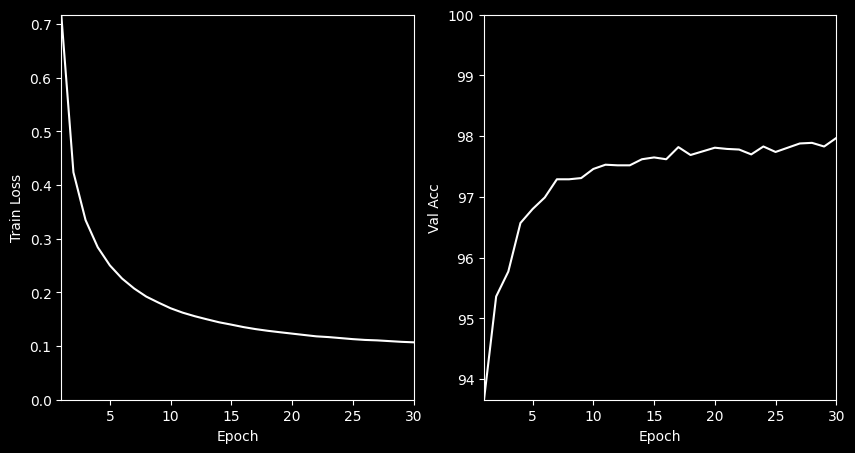

In [39]:
np.random.seed(42)


train = MNIST(root="data", train=True, download=True)
test = MNIST(root="data", train=False, download=True)

x_train, y_train = [], []
x_test, y_test = [], []

for image, label in train:
    x = [[pixel / 255.0] for pixel in image.getdata()]
    y = [[0.0] for _ in range(10)]
    y[label] = [1.0]

    x_train.append(x)
    y_train.append(y)


for image, label in test:
    x = [[pixel / 255.0] for pixel in image.getdata()]
    y = [[0.0] for _ in range(10)]
    y[label] = [1.0]

    x_test.append(x)
    y_test.append(y)

x_val = x_train[50000:]
y_val = y_train[50000:]

x_train = x_train[:50000]
y_train = y_train[:50000]


mlp = MLP(hidden_neurons=100)
batch_size = 10
epochs = 30
lr = 0.1
weight_decay = 1e-5

optim = Optimizer(lr=lr, batch_size=batch_size, weight_decay=weight_decay)
mlp.set_optim(optim=optim)

train_losses = []
val_accs = []
epochs_list = []


for i in range(epochs):
    num_train_samples = len(x_train)
    train_loss = 0.0

    combined = list(zip(x_train, y_train))
    np.random.shuffle(combined)
    x_train, y_train = zip(*combined)

    pbar = tqdm(total=num_train_samples, unit="samples")

    for batch_index in range(0, num_train_samples, batch_size):
        for offset in range(batch_size):
            s = batch_index + offset
            if (s >= num_train_samples): break

            x, y = x_train[s], y_train[s]
            preds = mlp(x)
            mlp.backward(x, y) 
            # sys.exit()
            loss = BCE(y, preds)
            train_loss += loss

            # if s % 1024 == 0: print(loss)
            pbar.update(1)
            # if (s % 1000 == 0): print(f"{s}/{num_samples}")

        mlp.step()
        mlp.clear_grad()


    pbar.close()

    train_loss += L2(mlp, optim) # L2 Regularization
    train_loss /= num_train_samples

    correct = 0.0
    num_val_samples = len(x_val)

    for s in range(num_val_samples):
        x, y = x_val[s], y_val[s]

        preds = mlp(x)
        correct += acc(y, preds)    

    val_acc = 100 * correct / num_val_samples   
        
    train_losses.append(train_loss)
    val_accs.append(val_acc)
    epochs_list.append(i+1)

    
    print(f"Epoch: {i+1} | Loss: {train_loss:.4f} | Acc: {val_acc:.2f}%")  

    plt.clf()
    plt.style.use("dark_background")
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.axis([1, epochs, 0, max(train_losses)])
    plt.plot(epochs_list, train_losses, c = "white")
    plt.xlabel("Epoch")
    plt.ylabel("Train Loss")

    plt.subplot(1, 2, 2)
    plt.axis([1, epochs, min(val_accs), 100])
    plt.plot(epochs_list, val_accs, c = "white")
    plt.xlabel("Epoch")
    plt.ylabel("Val Acc")

    plt.show()





In [40]:
correct = 0.0
num_test_samples = len(x_test)


for s in range(num_test_samples):
        x, y = x_test[s], y_test[s]

        preds = mlp(x)
        correct += acc(y, preds)
        
test_acc = 100 * correct / num_test_samples

print(f"Test Acc: {test_acc:.2f}%")

  

Test Acc: 97.81%
